In [1]:
!wget -nc http://lazyprogrammer.me/course_files/AirlineTweets.csv

--2026-03-26 15:17:24--  http://lazyprogrammer.me/course_files/AirlineTweets.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://lazyprogrammer.me/course_files/AirlineTweets.csv [following]
--2026-03-26 15:17:25--  https://lazyprogrammer.me/course_files/AirlineTweets.csv
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3421431 (3.3M) [text/csv]
Saving to: ‘AirlineTweets.csv’

AirlineTweets.csv   100%[===================>]   3.26M   624KB/s    in 6.5s    

2026-03-26 15:17:31 (514 KB/s) - ‘AirlineTweets.csv’ saved [3421431/3421431]



In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


In [3]:
df_ = pd.read_csv('AirlineTweets.csv')

In [4]:
df_.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
df = df_[['airline_sentiment', 'text']].copy()

In [6]:
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


<Axes: >

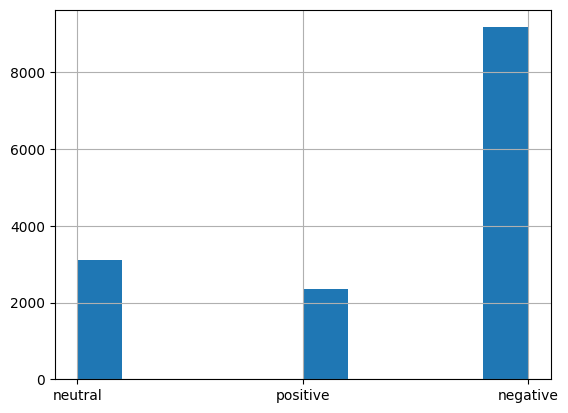

In [7]:
df['airline_sentiment'].hist()

In [8]:
target_map = {'positive': 1, 'negative': 0, 'neutral': 2}
df['target'] = df['airline_sentiment'].map(target_map)

In [10]:
df2 = df[['text', 'target']]
df2.columns = ['sentence', 'label']
df2.to_csv('data.csv', index=None)

In [11]:
!head data.csv

sentence,label
@VirginAmerica What @dhepburn said.,2
@VirginAmerica plus you've added commercials to the experience... tacky.,1
@VirginAmerica I didn't today... Must mean I need to take another trip!,2
"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",0
@VirginAmerica and it's a really big bad thing about it,0
"@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing about flying VA",0
"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",1
"@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP",2


In [12]:
from datasets import load_dataset
raw_dataset = load_dataset('csv', data_files='data.csv')

Generating train split: 0 examples [00:00, ? examples/s]

In [13]:
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 14640
    })
})

In [14]:
split = raw_dataset['train'].train_test_split(test_size=0.3, seed=42)

In [15]:
split

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 10248
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 4392
    })
})

In [16]:
### for multiple csv files
### load_dataset('csv', data_files=['file1.csv', 'file2.csv'])

### if you have a train-test split already:
# load_dataset(
#   'csv'
#   data_files={'train': ['train1.csv', 'train2.csv'],
#               'test': 'test.csv'
#   }
# )

In [17]:
checkpoint = 'distilbert-base-cased'

In [18]:
from transformers import AutoTokenizer

In [19]:
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [20]:
def tokenize_fn(batch):
    return tokenizer(batch['sentence'], truncation=True)

In [21]:
tokenized_datasets = split.map(tokenize_fn, batched=True)

Map:   0%|          | 0/10248 [00:00<?, ? examples/s]

Map:   0%|          | 0/4392 [00:00<?, ? examples/s]

In [23]:
from transformers import AutoModelForSequenceClassification, \
    Trainer, TrainingArguments

In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint, num_labels=3)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
!pip install torchinfo

In [28]:
from torchinfo import summary

In [29]:
summary(model)

Layer (type:depth-idx)                                  Param #
DistilBertForSequenceClassification                     --
├─DistilBertModel: 1-1                                  --
│    └─Embeddings: 2-1                                  --
│    │    └─Embedding: 3-1                              22,268,928
│    │    └─Embedding: 3-2                              393,216
│    │    └─LayerNorm: 3-3                              1,536
│    │    └─Dropout: 3-4                                --
│    └─Transformer: 2-2                                 --
│    │    └─ModuleList: 3-5                             42,527,232
├─Linear: 1-2                                           590,592
├─Linear: 1-3                                           2,307
├─Dropout: 1-4                                          --
Total params: 65,783,811
Trainable params: 65,783,811
Non-trainable params: 0

In [30]:
training_args = TrainingArguments(
    output_dir='training_dir',
    eval_strategy="epoch", # used to be evaluation_strategy, not anymore
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
)

In [31]:
def compute_metrics(logits_and_labels):
    logits, labels = logits_and_labels
    predictions = np.argmax(logits, axis=-1)
    acc = np.mean(predictions == labels)
    f1 = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'f1': f1}

In [33]:
trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    processing_class=tokenizer, # new way to pass the tokenizer
    compute_metrics=compute_metrics,
)

In [34]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.541837,0.455403,0.829235,0.765916
2,0.348392,0.487750,0.831740,0.770563
3,0.247223,0.626866,0.830829,0.774884


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1923, training_loss=0.3294771564422147, metrics={'train_runtime': 194.1354, 'train_samples_per_second': 158.364, 'train_steps_per_second': 9.905, 'total_flos': 388537948763424.0, 'train_loss': 0.3294771564422147, 'epoch': 3.0})

In [35]:
!ls training_dir/

checkpoint-1282  checkpoint-1923  checkpoint-641


In [37]:
from transformers import pipeline

In [60]:
savedmodel = pipeline('text-classification',
                      model='training_dir/checkpoint-1282',
                      device=0
                      )

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [40]:
split['test']

Dataset({
    features: ['sentence', 'label'],
    num_rows: 4392
})

In [55]:
len(split['test'])

4392

In [47]:
tokenized_datasets['test']['sentence']

Column(['@JetBlue thank you!', '@united thanks', "@SouthwestAir Thank you. The email about RR pts &amp; how to gain more wasn't clear so all of mine r gone. Anything u can do is appreciated.", "@AmericanAir Yes, thanks I found those, didn't see the gray tab at first :)", "@SouthwestAir my bday was yesterday and my girl gave birth to my first born and I couldn't get a courtesy flight change from Lynn... THANKS!"])

In [57]:
test_pred = [savedmodel(split['test']['sentence'][i]) for i in range(len(split['test']))]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [64]:
test_pred2 = savedmodel(list(split['test']['sentence']))

In [68]:
test_pred[0:4]

[[{'label': 'LABEL_1', 'score': 0.8968780636787415}],
 [{'label': 'LABEL_1', 'score': 0.9373332858085632}],
 [{'label': 'LABEL_0', 'score': 0.8116686940193176}],
 [{'label': 'LABEL_1', 'score': 0.7995722889900208}]]

In [69]:
test_pred2[0:4]

[{'label': 'LABEL_1', 'score': 0.8968780636787415},
 {'label': 'LABEL_1', 'score': 0.9373332858085632},
 {'label': 'LABEL_0', 'score': 0.8116686940193176},
 {'label': 'LABEL_1', 'score': 0.7995722889900208}]

In [71]:
# we stick to test_pred2 since that's the expected output
def get_label(d):
    return int(d['label'].split('_')[-1])

test_pred2_labels = [get_label(d) for d in test_pred2]

In [74]:
test_pred2_labels[0:5]

[1, 1, 0, 1, 2]

In [75]:
print("acc:", accuracy_score(split['test']['label'], test_pred2_labels))

acc: 0.8317395264116576


In [77]:
print("f1:", f1_score(split['test']['label'], test_pred2_labels, average='macro'))

f1: 0.7705627189373244


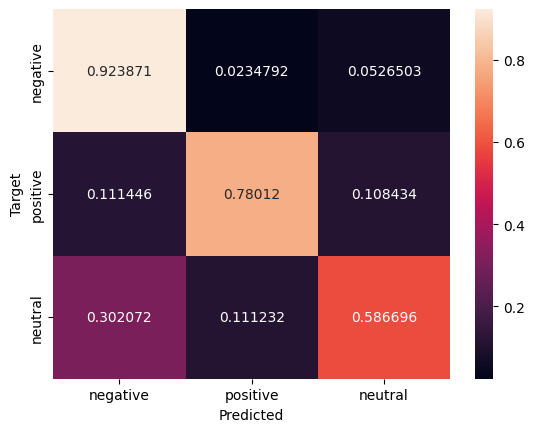

In [80]:
# old plotting code in case we don't have V1 of scikit-learn
def plot_cm(cm):
    classes = ['negative', 'positive', 'neutral']
    df_cm = pd.DataFrame(cm, index=classes, columns=classes)
    ax = sn.heatmap(df_cm, annot=True, fmt='g')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Target')

cm = confusion_matrix(split['test']['label'], test_pred2_labels, normalize='true')
plot_cm(cm)

<Axes: >

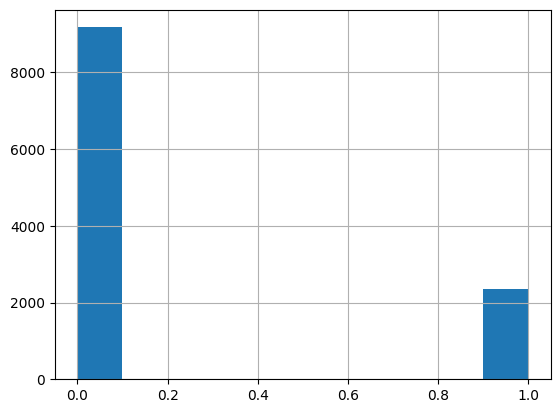

In [81]:
df3 = df2[df2['label'] != 2]
df3['label'].hist()

In [82]:
df3.to_csv('data2.csv', index=None)
raw_dataset2 = load_dataset('csv', data_files='data2.csv')

Generating train split: 0 examples [00:00, ? examples/s]

In [83]:
split2 = raw_dataset2['train'].train_test_split(test_size=0.3, seed=42)

In [84]:
split2

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 8078
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 3463
    })
})

In [85]:
tokenized_datasets2 = split2.map(tokenize_fn, batched=True)

Map:   0%|          | 0/8078 [00:00<?, ? examples/s]

Map:   0%|          | 0/3463 [00:00<?, ? examples/s]

In [86]:
model2 = AutoModelForSequenceClassification.from_pretrained(
    checkpoint, num_labels=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [87]:
training_args2 = TrainingArguments(
    output_dir='training_dir2',
    eval_strategy="epoch", # used to be evaluation_strategy, not anymore
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
)

In [88]:
trainer2 = Trainer(
    model2,
    training_args2,
    train_dataset=tokenized_datasets2['train'],
    eval_dataset=tokenized_datasets2['test'],
    processing_class=tokenizer, # new way to pass the tokenizer
    compute_metrics=compute_metrics,
)

In [89]:
trainer2.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.231890,0.176218,0.937915,0.900248
2,0.107171,0.222585,0.939936,0.905055
3,0.047037,0.277066,0.941092,0.904199


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1515, training_loss=0.1280760620293444, metrics={'train_runtime': 162.0451, 'train_samples_per_second': 149.551, 'train_steps_per_second': 9.349, 'total_flos': 303120594777696.0, 'train_loss': 0.1280760620293444, 'epoch': 3.0})

In [90]:
!ls training_dir2/

checkpoint-1010  checkpoint-1515  checkpoint-505


In [91]:
savedmodel2 = pipeline('text-classification',
                      model='training_dir2/checkpoint-1515',
                      device=0
                      )

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [99]:
test_pred3 = savedmodel2(list(split2['test']['sentence']))

In [100]:
test_pred3_labels = [get_label(d) for d in test_pred3]

In [101]:
print("acc:", accuracy_score(split2['test']['label'], test_pred3_labels))

acc: 0.9410915391279238


In [102]:
print("f1:", f1_score(split2['test']['label'], test_pred3_labels, average='macro'))

f1: 0.9041990906635162


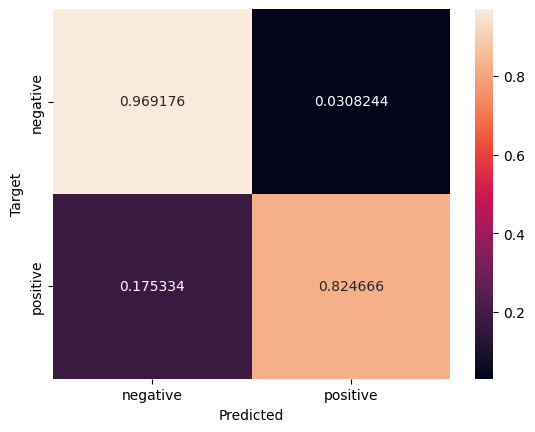

In [103]:
def plot_cm2(cm):
    classes = ['negative', 'positive']
    df_cm = pd.DataFrame(cm, index=classes, columns=classes)
    ax = sn.heatmap(df_cm, annot=True, fmt='g')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Target')

cm2 = confusion_matrix(split2['test']['label'], test_pred3_labels, normalize='true')
plot_cm2(cm2)